# Optimal Analysis

In [93]:
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import os

In [ ]:
import sys
import os

# Get the path to the directory containing 'scripts/' 
# (assuming your notebook is in the project root or a sibling folder)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
scripts_path = os.path.join(project_root, "scripts")

if scripts_path not in sys.path:
    sys.path.insert(0, scripts_path)

In [2]:
sc.set_figure_params(figsize=(6, 6), frameon=False)

In [132]:
rev_n = 12 # Use 12
region = 'hippocampus' # Options: 'cerebral_cortex', 'hippocampus'
path_to_data = f"/home/ratopin/big_data/nmr/{region}_nmr_adata_filtered{rev_n}.h5ad"

In [ ]:
### PARAMETERS
batch_key = "sample"
n_hvg = 6000
n_neighb = 25


In [134]:
adata = sc.read_h5ad(path_to_data)
adata.obs_names_make_unique()
print(adata)

AnnData object with n_obs × n_vars = 13634 × 17592
    obs: 'species', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_tf', 'log1p_total_counts_tf', 'pct_counts_tf', 'n_counts', 'qc_composite', 'qc_label', 'sample_id', 'replicate'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'


## Quality control
QC was already performed in `main_preprocessing.ipynb`

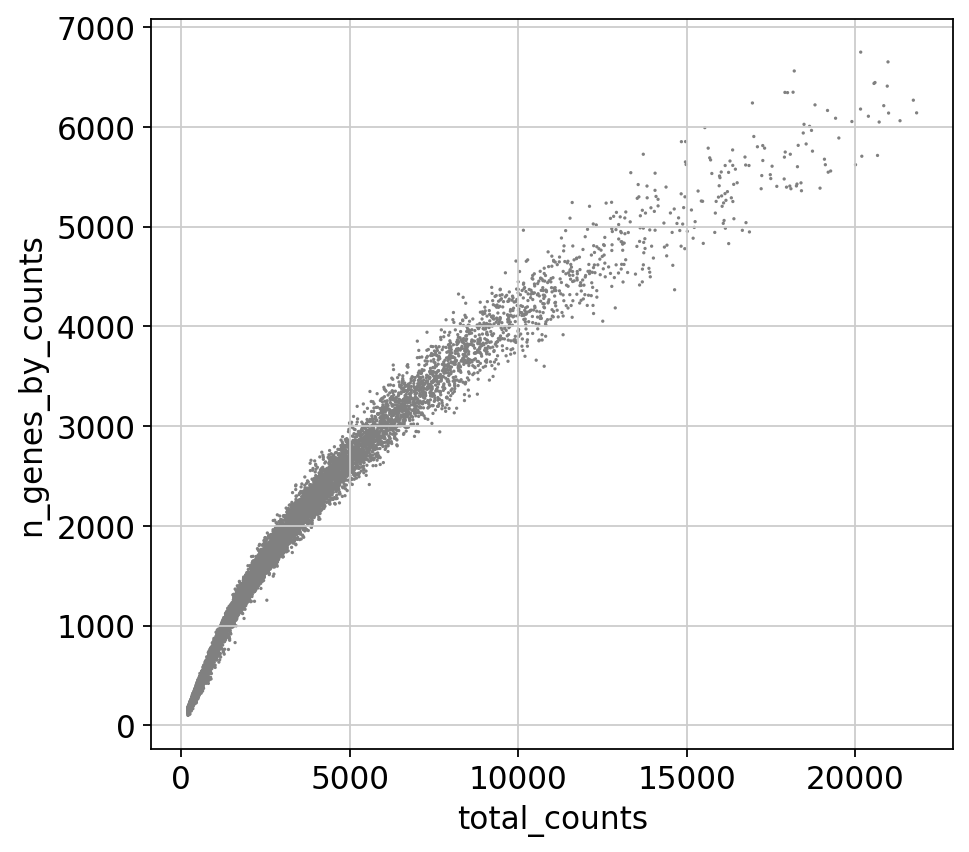

In [135]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts")

In [136]:
sc.pp.highly_variable_genes(
    adata, 
    n_top_genes=n_hvg, 
    subset=False, 
    flavor="seurat_v3", 
    batch_key=batch_key
)

# Store raw counts in a layer for later use in DE analysis
adata.layers["counts"] = adata.X.copy()

# Standard normalization and log transformation
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.scale(adata, max_value=10)
sc.pp.pca(adata, svd_solver='arpack')


In [ ]:
import sys
import os

module_dir = os.path.abspath('../scripts/')
sys.path.append(module_dir)
from plot_functions import plot_highly_variable_genes, plot_3d_pca_gene

... storing 'is_highly_variable' as categorical


Axes: Axes(0.11744,0.15;0.588373x0.76)


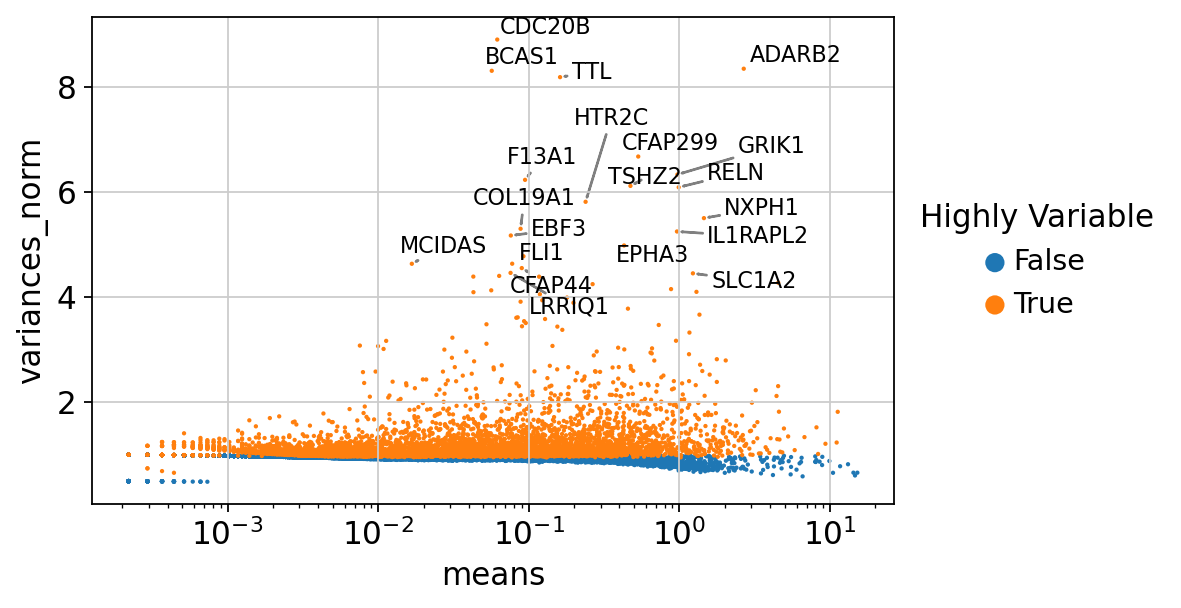

In [ ]:
plot_highly_variable_genes(adata, save_suffix=region, n_top_genes=20, figsize=(6,4))

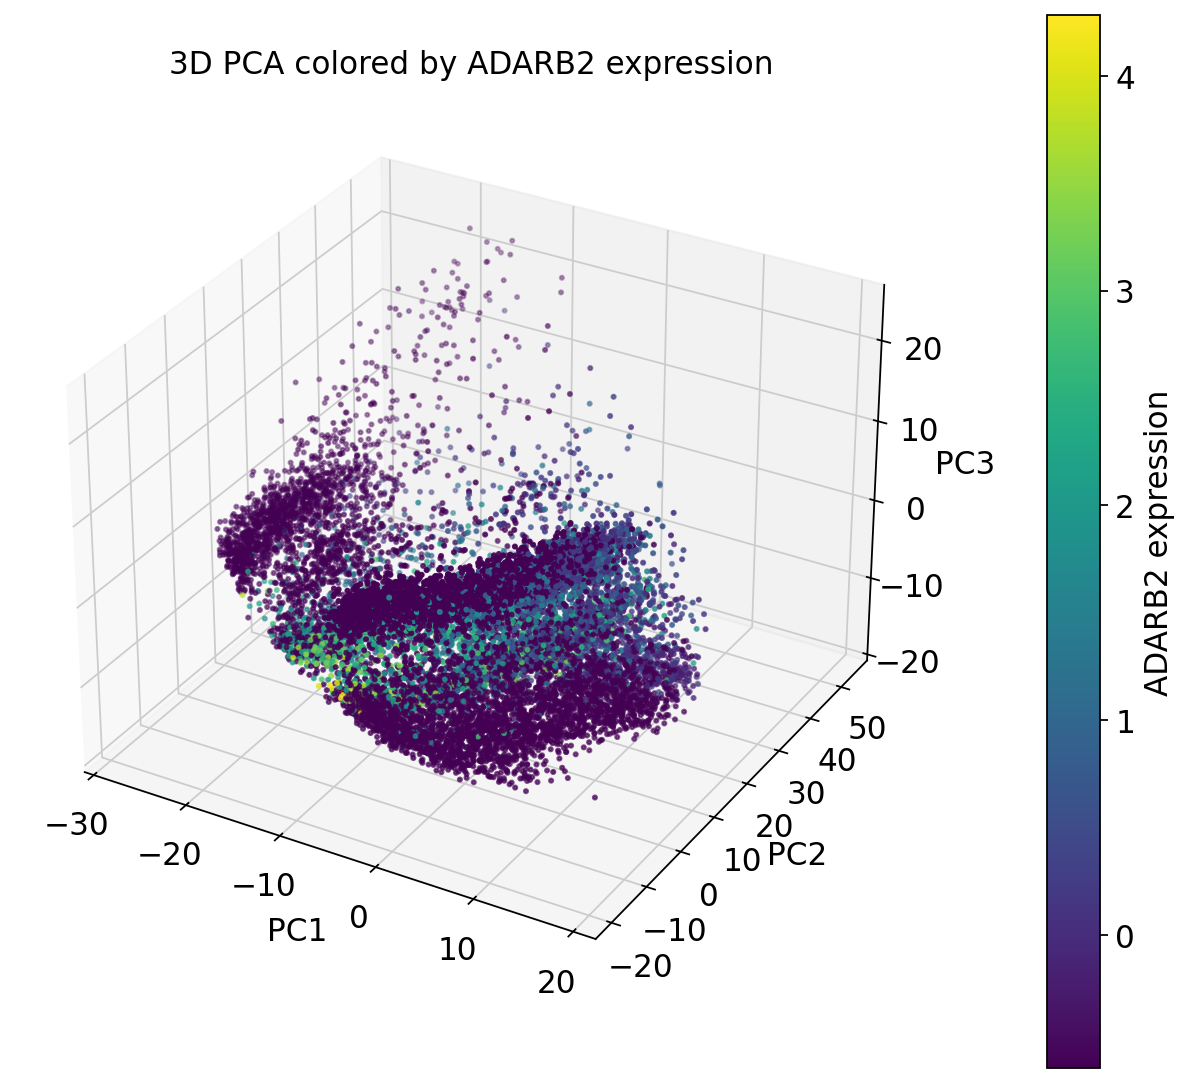

In [ ]:
plot_3d_pca_gene(adata, gene="ADARB2", save_prefix=region, save_fig=True, figsize=(8,7))

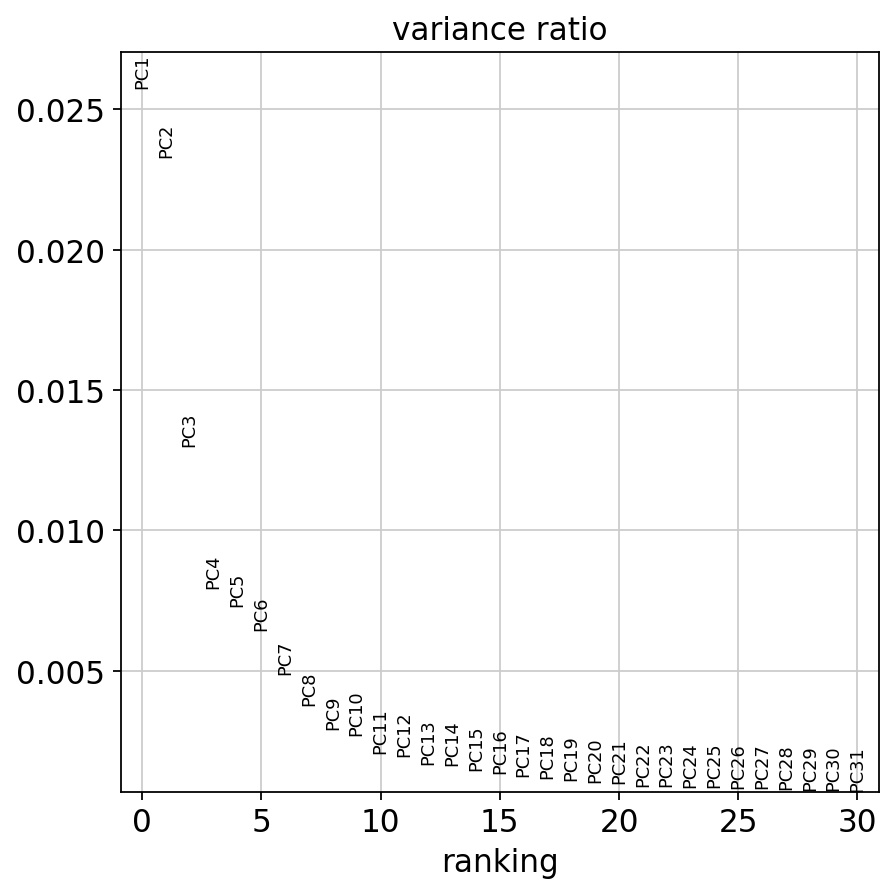

In [139]:
sc.pl.pca_variance_ratio(adata, log=False, save=f"_{region}_pca_variance.png", )

In [140]:
import harmonypy as hm 
harmony_out = hm.run_harmony(adata.obsm['X_pca'], 
    adata.obs, 
    batch_key, 
    max_iter_harmony=20, 
    max_iter_kmeans=3, # (Maximum number of iterations for k-means clustering) Default is 4, higher values -> more aggressive batch correction
    theta=1.5, # (Diversity penalty per batch variable) Default is 2, higher values -> more aggressive batch correction
    lamb=1, # (Ridge penalty) Default is 1, higher values -> more aggressive batch correction
    sigma=0.1, # (Kernel bandwidth for soft clustering) Default is 0.1, lower values -> more aggressive batch correction
    verbose=True)
adata.obsm['X_pca_harmony'] = harmony_out.Z_corr 

2026-05-22 17:20:20,965 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
Running Harmony (PyTorch on cpu)
2026-05-22 17:20:20,966 - harmonypy - INFO -   Parameters:
  Parameters:
2026-05-22 17:20:20,967 - harmonypy - INFO -     max_iter_harmony: 20
    max_iter_harmony: 20
2026-05-22 17:20:20,968 - harmonypy - INFO -     max_iter_kmeans: 3
    max_iter_kmeans: 3
2026-05-22 17:20:20,969 - harmonypy - INFO -     epsilon_cluster: 1e-05
    epsilon_cluster: 1e-05
2026-05-22 17:20:20,970 - harmonypy - INFO -     epsilon_harmony: 0.0001
    epsilon_harmony: 0.0001
2026-05-22 17:20:20,971 - harmonypy - INFO -     nclust: 100
    nclust: 100
2026-05-22 17:20:20,971 - harmonypy - INFO -     block_size: 0.05
    block_size: 0.05
2026-05-22 17:20:20,972 - harmonypy - INFO -     lamb: [1. 1.]
    lamb: [1. 1.]
2026-05-22 17:20:20,973 - harmonypy - INFO -     theta: [1.5 1.5]
    theta: [1.5 1.5]
2026-05-22 17:20:20,974 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
    sigma: [0.1 0

In [141]:
sc.pp.neighbors(adata, use_rep="X_pca_harmony", n_neighbors=n_neighb)


In [144]:
sc.tl.umap(adata)


... storing 'is_highly_variable' as categorical


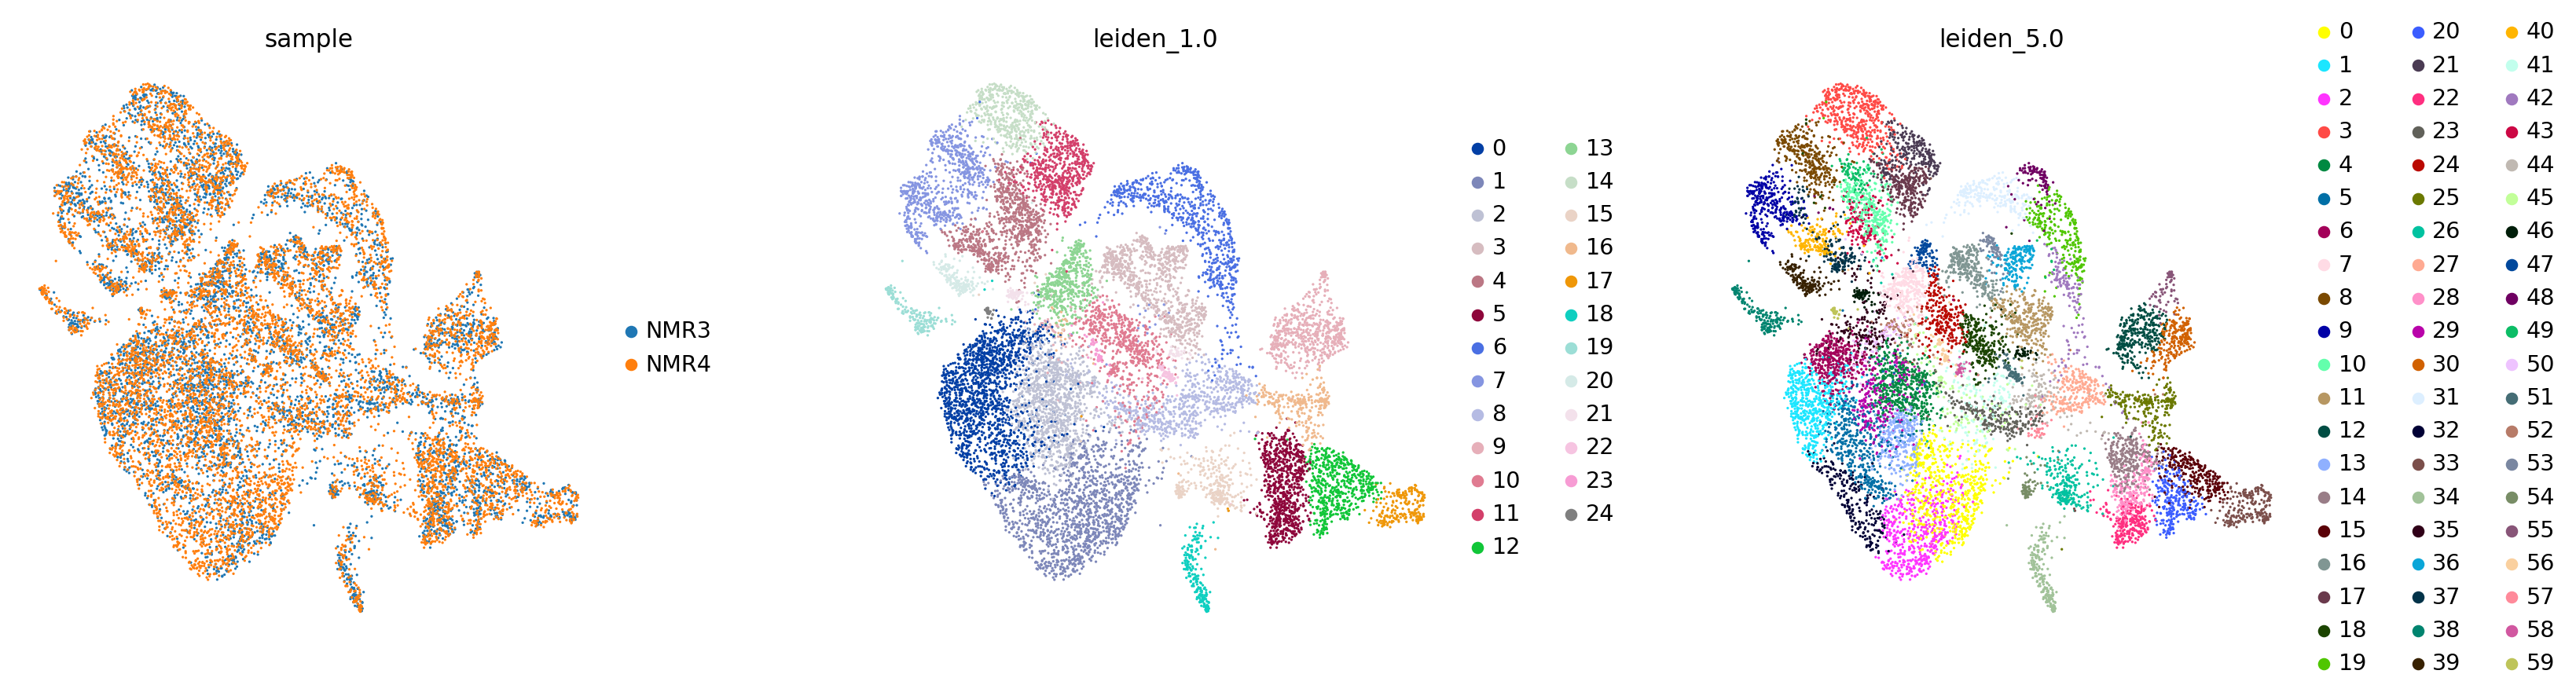

In [ ]:
sc.pl.umap(adata, color=[batch_key], wspace=0.3)

In [146]:
output_path = f"/home/ratopin/big_data/nmr/{region}_nmr_adata_optimal{rev_n}.h5ad"
adata.write_h5ad(output_path)
print(f"Processed data saved to {output_path}")

Processed data saved to /home/ratopin/big_data/nmr/hippocampus_nmr_adata_optimal12.h5ad
